In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df.shape

(2484, 4)

In [4]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [5]:
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

## Create a Job Description

In [6]:
job_description = """
Python
Java
SQL
Machine Learning
Data Structures
Algorithms
Problem Solving
Git
Data Analysis
"""

In [7]:
resumes = df['Resume_str'].astype(str)

In [8]:
all_text = [job_description] + resumes.tolist()

## TF-IDF Vectorization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(all_text)

## Calculate Similarity

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

## Add Match Scores

In [11]:
df['Match Score'] = similarity_scores[0] * 100

## Rank Candidates

In [12]:
top_candidates = df.sort_values(
    by='Match Score',
    ascending=False
)

top_candidates[
    ['Category', 'Match Score']
].head(10)

,Category,Match Score
1218,CONSULTANT,31.002619
1762,ENGINEERING,28.322345
1142,CONSULTANT,24.860216
297,INFORMATION-TECHNOLOGY,22.713520
1348,AUTOMOBILE,22.282339
1339,AUTOMOBILE,21.746532
2457,AVIATION,21.492344
662,BUSINESS-DEVELOPMENT,20.860483
1303,DIGITAL-MEDIA,20.583013
331,INFORMATION-TECHNOLOGY,19.498201


## Skill Gap Identification

In [13]:
required_skills = {
    'python',
    'java',
    'sql',
    'machine learning',
    'git'
}

In [14]:
resume_text = resumes.iloc[0].lower()

missing_skills = []

for skill in required_skills:
    if skill not in resume_text:
        missing_skills.append(skill)

print("Missing Skills:", missing_skills)

Missing Skills: ['machine learning', 'python', 'java', 'sql', 'git']


## Visualization

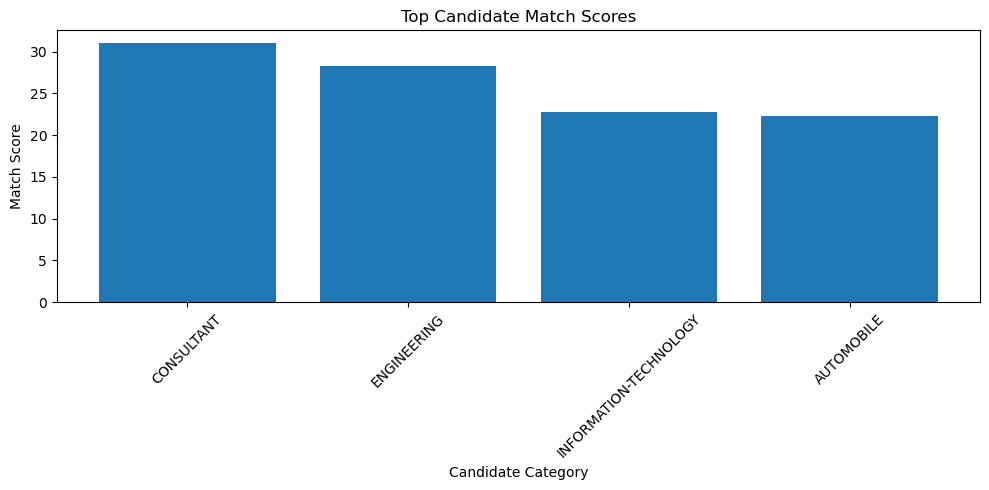

In [15]:
import matplotlib.pyplot as plt

top5 = top_candidates.head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5['Category'],
    top5['Match Score']
)

plt.xticks(rotation=45)

plt.title("Top Candidate Match Scores")
plt.xlabel("Candidate Category")
plt.ylabel("Match Score")

plt.tight_layout()
plt.show()

## Display Top Candidates

In [16]:
top_candidates[
    ['Category', 'Match Score']
].head(10)

,Category,Match Score
1218,CONSULTANT,31.002619
1762,ENGINEERING,28.322345
1142,CONSULTANT,24.860216
297,INFORMATION-TECHNOLOGY,22.713520
1348,AUTOMOBILE,22.282339
1339,AUTOMOBILE,21.746532
2457,AVIATION,21.492344
662,BUSINESS-DEVELOPMENT,20.860483
1303,DIGITAL-MEDIA,20.583013
331,INFORMATION-TECHNOLOGY,19.498201


## Skill Gap Identification

In [17]:
required_skills = {
    'python',
    'java',
    'sql',
    'machine learning',
    'git'
}

resume_text = resumes.iloc[0].lower()

missing_skills = []

for skill in required_skills:
    if skill not in resume_text:
        missing_skills.append(skill)

print("Missing Skills:")
print(missing_skills)

Missing Skills:
['machine learning', 'python', 'java', 'sql', 'git']


 ## Conclusion

A Resume/Candidate Screening System was successfully developed using Natural Language Processing (NLP) techniques. Resume text and job descriptions were converted into numerical features using TF-IDF Vectorization, and candidate suitability was measured using Cosine Similarity.

The system automatically ranked candidates according to their match scores and identified missing skills required for the target job role. This project demonstrates how NLP and Machine Learning techniques can automate resume screening, reduce manual effort in recruitment, and assist recruiters in identifying suitable candidates more efficiently.

Future improvements can include extracting skills directly from PDF resumes, incorporating semantic embeddings using transformer-based models such as BERT, and building a web application for real-time resume screening.